## Time-varying DDM

Autocorrelated fluctuations in $v$, $z$, and $a$

In [1]:
import numpy as np
import os
from numba import njit
import bayesflow as bf
import tensorflow as tf
from functions import _CustomTwoLevelPrior, _Custom_Simulator, _CustomTwoLevelGenerativeModel
from scipy.stats import beta, gamma, uniform, spearmanr, pearsonr
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib import cm
import seaborn as sns
import math
import pandas as pd

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32

import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)
from tensorflow.python.platform import build_info as tf_build_info
print("cudnn_version",tf_build_info.build_info['cudnn_version'])
print("cuda_version",tf_build_info.build_info['cuda_version'])

2026-09-23 17:10:54.389716: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-23 17:10:54.421878: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-23 17:10:54.421917: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-23 17:10:54.422969: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-23 17:10:54.428604: I tensorflow/core/platform/cpu_feature_guar

2026-09-23 17:10:55.826768: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cudnn_version 8
cuda_version 12.2


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-09-23 17:11:01.492714: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
# Create folder if it does not exist
os.makedirs("Figures", exist_ok=True)
os.makedirs("Data", exist_ok=True)

## Set priors

In [4]:
RNG = np.random.default_rng(0)

min_n_trials = 500
max_n_trials = 500

batch_size = 32

"""
Set parameters for prior distributions 
"""

# uniform for drift rate, starting point, boundary, and non-decision time
v_lower, v_upper = 0.0, 5.0
z_lower, z_upper = -2.0, 2.0
a_lower, a_upper = 0.1, 5.0
ter_lower, ter_upper = 0.01, 1.0

# uniform for phi and sigma of AR(1) process
phi_v_bias_lower, phi_v_bias_upper = 0.0, 1.0
phi_z_bias_lower, phi_z_bias_upper = 0.0, 1.0
phi_a_bias_lower, phi_a_bias_upper = 0.0, 1.0

sigma_v_bias_lower, sigma_v_bias_upper = 0.0, 4.0
sigma_z_bias_lower, sigma_z_bias_upper = 0.0, 2.0
sigma_a_bias_lower, sigma_a_bias_upper = 0.0, 2.0

## Prior functions

In [5]:
def sample_shared_parameters():
    """
    Shared parameters are parameters that stay constant over trials within a subject
    and are not related to the AR(1) processes for starting point bias and drift bias
    """
    
    v = np.random.uniform(v_lower, v_upper) # drift rate
    z = np.random.uniform(z_lower, z_upper) # starting point (relative to boundary)
    a = np.random.uniform(a_lower, a_upper) # boundary
    ter = np.random.uniform(ter_lower, ter_upper) # non-decision time
    
    shared_parameters = np.concatenate([np.r_[v, z, a, ter]])
    
    return shared_parameters
    

In [6]:
def sample_hyper_parameters():
    """
    Hyper parameters govern the AR(1) process for starting point bias and drift bias.
    Following hyper parameters are sampled separately for the AR(1) of starting point bias and drift bias:    
    autoregressive coefficient (phi), and sigma.
    
    Note that the fluctuating value for starting point is a actually a bias that we add to 
    the .5 to obtain the starting point (see def _sample_one_diffusion_trial)
    This is easier to implement than a time series that should fluctuate around .5, 
    """
    
    phi_v_bias = np.random.uniform(phi_v_bias_lower, phi_v_bias_upper)
    phi_z_bias = np.random.uniform(phi_z_bias_lower, phi_z_bias_upper)
    phi_a_bias = np.random.uniform(phi_a_bias_lower, phi_a_bias_upper)

    sigma_v_bias = np.random.uniform(sigma_v_bias_lower, sigma_v_bias_upper)
    sigma_z_bias = np.random.uniform(sigma_z_bias_lower, sigma_z_bias_upper)
    sigma_a_bias = np.random.uniform(sigma_a_bias_lower, sigma_a_bias_upper)

    hyper_parameters = np.concatenate([np.r_[phi_v_bias, sigma_v_bias, phi_z_bias, sigma_z_bias, phi_a_bias, sigma_a_bias]])
    
    return hyper_parameters
    

In [7]:
def sample_local_parameters(shared_parameters, hyper_parameters, condition_matrix, num_trials): # hyper_params, local_batchable_context, local_non_batchable_context provided by local_context_generator in TwoLevelPrior
    """
    Local parameters are the trial-to-trial fluctuations in drift bias and starting point bias
    Takes in hyperparameters for AR(1) process
    """
    
    a = shared_parameters[2]
    
    phi_v_bias = hyper_parameters[0]
    sigma_v_bias = hyper_parameters[1]
    
    phi_z_bias = hyper_parameters[2]
    sigma_z_bias = hyper_parameters[3]
    
    phi_a_bias = hyper_parameters[4]
    sigma_a_bias = hyper_parameters[5]
    
    # Initialize first value for drift bias (first column), starting point bias (second column), boundary bias (third column)
    local_parameters = np.zeros((num_trials,3))
    
    local_parameters[0,0] = 0.0
    local_parameters[0,1] = 0.0
    local_parameters[0,2] = 0.0
    
    # Run AR(1) from initial value: x_t = phi * x_t-1 + N(0,sigma)
    for t in range(1, num_trials):
        
        # Drift bias
        local_parameters[t,0] = phi_v_bias * local_parameters[t-1, 0] + np.random.normal(0.0, sigma_v_bias) 

        # Starting point bias
        local_parameters[t,1] = phi_z_bias * local_parameters[t-1, 1] + np.random.normal(0.0, sigma_z_bias) 
        
        # Boundary bias
        local_parameters[t,2] = np.clip(
                                phi_a_bias * local_parameters[t-1, 2] + np.random.normal(0.0, sigma_a_bias),
                                a_min=0.1-a, a_max=1e5 # restrict a_t such that a + a_t is always > 0.1
                                )

    return local_parameters
    

## Sample diffusion trial

In [8]:
@cuda.jit
def _sample_one_diffusion_trial(rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias, num_threads):
    """
    Generates a single response time from a Diffusion Decision process.
    """
    
    thread_id = cuda.grid(1)
    
    if (thread_id < num_threads):
        
        # Input parameters
        v = in_v[thread_id]
        z = in_z[thread_id]
        a = in_a[thread_id]
        ter = in_ter[thread_id]
        v_bias = in_v_bias[thread_id]
        z_bias = in_z_bias[thread_id]
        a_bias = in_a_bias[thread_id]
        
        # Simulation parameters
        dt=0.005             # time resolution of process, 5 milliseconds
        max_iter=int(20/dt)  # max iterations of the process, 20 seconds
        s=1.0                # scaling factor of the Wiener noise
        c = (dt * s)**0.5    # np.sqrt does not work with cuda.jit     

        # Initialize
        transformed_z = 1/(1+math.exp(-(z+z_bias))) # constrain z + z_bias between 0 and 1 with sigmoid transformation
        evidence = (a+a_bias) * (transformed_z)     # initialize first value (starting point plus bias relative to boundary)
        slope = v+v_bias                            # v and v_bias are both already multiplied with stimulus (effectively making 'slope' a fluctuating drift rate)
        slope_dt = slope*dt
        n_iter = 0
        
        # Diffusion process
        while evidence > 0 and evidence < (a+a_bias) and n_iter < max_iter:
            n_iter += 1
            evidence += slope_dt + c * xoroshiro128p_normal_float32(rng_states, thread_id)
    
        # Determine response
        rt = n_iter * dt + ter
        
        if evidence >= (a+a_bias):
            resp =  1
        elif evidence <= 0:
            resp = 0
        else:
            resp = -99
            
        out_rt[thread_id] = rt
        out_resp[thread_id] = resp

## Cuda helper functions

In [9]:
@njit(fastmath=True)
def cuda_convert_parameters(parameters, condition_matrix):
    """
    Convert the batched parameters into a vector for each parameter separately
    """
    
    local_parameters = parameters[0]
    shared_parameters = parameters[1]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    in_v = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_ter = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_v_bias = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z_bias = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a_bias = np.zeros(batch_size * num_trials, dtype=np.float32)

    for dataset in range(batch_size): # loop over datasets
    
        local_parameters_subset = local_parameters[dataset]
        shared_parameters_subset = shared_parameters[dataset]
        condition_matrix_subset = condition_matrix[dataset]
        
        for trial in range(num_trials): # loop over trials
                
            in_index = dataset * num_trials + trial

            in_v[in_index] = shared_parameters_subset[0] * condition_matrix_subset[trial] # multiply drift rate with stimulus
            in_z[in_index] = shared_parameters_subset[1]
            in_a[in_index] = shared_parameters_subset[2]
            in_ter[in_index] = shared_parameters_subset[3]
            in_v_bias[in_index] = local_parameters_subset[trial,0] * condition_matrix_subset[trial] # by multiplying with stimulus here we effectively create a fluctuating drift rate, instead of drift bias
            in_z_bias[in_index] = local_parameters_subset[trial,1]
            in_a_bias[in_index] = local_parameters_subset[trial,2]

    return in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias


@njit(fastmath=True)
def cuda_convert_sim_data(parameters, condition_matrix, out_rt, out_resp):
    
    local_parameters = parameters[0]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    out = np.zeros((batch_size, num_trials, 2), dtype=np.float32) # rt, resp

    for dataset in range(batch_size): # loop over datasets
        for trial in range(num_trials): # loop over trials

            # simulated data as a 3D tensor of shape (num_datasets, num_trials, num_variables)
            out_index = dataset * num_trials + trial
            out[dataset, trial, :] = np.array([out_rt[out_index], out_resp[out_index]], dtype=np.float32)

    return out

## Sample multiple diffusion trials

In [10]:
def sample_multiple_diffusion_trials(parameters, condition_matrix): # condition matrix is given by _CustomTwoLevelGenerativeModel as batchable_context (see functions.py line 484)
    """Generates a single simulation from DDM with starting point bias and
    drift bias following an AR(1) model.

    parameters : a tuple consisting of (local_parameters, shared_parameters)
                 as returned by the generator function to the simulator (likelihood) function
                 see source code https://bayesflow.org/_modules/bayesflow/amortizers.html#TwoLevelAmortizedPosterior
    """

    local_parameters = parameters[0]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    threads_per_block = 32
    total_threads = int(batch_size * num_trials)
    blocks = math.ceil(total_threads / threads_per_block)
    rng_states = create_xoroshiro128p_states(total_threads, seed=0)
    
    # parameters and conditions_matrix should be batched! 
    in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias = cuda_convert_parameters(parameters, condition_matrix)    
    
    # one iteration happens fully in parallel (so each trial for all datasets in parallel)
    out_rt = np.zeros(batch_size * num_trials, dtype=np.float32)
    out_resp = np.zeros(batch_size * num_trials, dtype=np.float32)

    _sample_one_diffusion_trial[blocks, threads_per_block](rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias, total_threads)

    out = cuda_convert_sim_data(parameters, condition_matrix, out_rt, out_resp)
    
    return out

## Helper functions

In [11]:
def return_mean_std_shared_parameters():
    """
    Return the mean and standard deviation of shared parameters
    """
    
    v_mean, v_std = uniform.stats(v_lower, v_upper, moments='mv')
    z_mean, z_std = uniform.stats(z_lower, z_upper, moments='mv')
    a_mean, a_std =  uniform.stats(a_lower, a_upper, moments='mv')
    ter_mean, ter_std =  uniform.stats(ter_lower, ter_upper, moments='mv')
    
    mean_shared = np.array([v_mean, z_mean, a_mean, ter_mean])
    std_shared = np.array([v_std, z_std, a_std, ter_std])
    
    return mean_shared, std_shared



def return_mean_std_hyper_parameters():
    """
    Return the mean and standard deviation of hyperparameters 
    """
    
    phi_v_bias_mean, phi_v_bias_var = uniform.stats(phi_v_bias_lower, phi_v_bias_upper, moments='mv')
    phi_z_bias_mean, phi_z_bias_var = uniform.stats(phi_z_bias_lower, phi_z_bias_upper, moments='mv')
    phi_a_bias_mean, phi_a_bias_var = uniform.stats(phi_a_bias_lower, phi_a_bias_upper, moments='mv')
    
    sigma_v_bias_mean, sigma_v_bias_var = uniform.stats(sigma_v_bias_lower, sigma_v_bias_upper, moments='mv')
    sigma_z_bias_mean, sigma_z_bias_var = uniform.stats(sigma_z_bias_lower, sigma_z_bias_upper, moments='mv')    
    sigma_a_bias_mean, sigma_a_bias_var = uniform.stats(sigma_a_bias_lower, sigma_a_bias_upper, moments='mv')  
    
    # must have same order as output from sample_hyper_parameters()
    mean_hyper = np.array([phi_v_bias_mean, sigma_v_bias_mean, phi_z_bias_mean, sigma_z_bias_mean, phi_a_bias_mean, sigma_a_bias_mean])
    std_hyper = np.sqrt(np.array([phi_v_bias_var, sigma_v_bias_var, phi_z_bias_var, sigma_z_bias_var, phi_a_bias_var, sigma_a_bias_var]))
    
    return mean_hyper, std_hyper

In [12]:
def sample_n_trials(min_n_trials=min_n_trials, max_n_trials=max_n_trials):
    """
    Samples the number of trials used for all simulations in one batch.
    """
    
    num_trials = np.random.randint(min_n_trials, max_n_trials+1)
    
    return num_trials



def generate_condition_matrix(num_trials):
    """
    Draws a random design matrix (stimulus: either -1 or +1 on each trial) for each simulation in a batch.
    """

    condition_matrix = np.random.uniform(-1, 1, size=num_trials)

    return condition_matrix


## Setting up generator

In [13]:
""" 
6 hyper parameters (phi_v_bias, phi_z_bias, phi_a_bias, sigma_v_bias, sigma_z_bias, sigma_a_bias)
3 local parameters (v_bias, z_bias, a_bias)
4 shared parameters (v, a, z, ter)
"""

experimental_context = bf.simulation.ContextGenerator(non_batchable_context_fun=sample_n_trials,
                                                      batchable_context_fun=generate_condition_matrix,
                                                      use_non_batchable_for_batchable=True)

prior = _CustomTwoLevelPrior( # custom function that enables local parameters to be constrained by shared parameters (if relu1 for z bias and z is used)
    hyper_prior_fun=sample_hyper_parameters,
    local_prior_fun=sample_local_parameters,
    shared_prior_fun=sample_shared_parameters,
    local_context_generator=experimental_context # provides num_trials and condition_matrix to local_prior_fun (see source code https://bayesflow.org/_modules/bayesflow/simulation.html#TwoLevelPrior)
)

# likelihood only takes in local and shared priors, not the hyper priors (see source code https://bayesflow.org/_modules/bayesflow/simulation.html#TwoLevelGenerativeModel)
# generator outputs both parameters (local and shared priors, not hyper) and batchable context to likelihood 
# _Custom_Simulator makes sure that the batchable context (condition matrix) from prior is used, despite empty context_generator here in likelihood function
likelihood = _Custom_Simulator(
     batch_simulator_fun=sample_multiple_diffusion_trials
)

# _CustomTwoLevelGenerativeModel: outputs both parameters and batchable context (design_matrix) from prior to likelihood as input, see line 484 in functions.py
generator = _CustomTwoLevelGenerativeModel(
     prior=prior,
     simulator=likelihood,
     name="ar1_ddm"
 )


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 32 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/cuda/core/experimental/_linker.py:189: RuntimeWarning: nvJitLink is not installed or too old (<12.3). Therefore it is not usable and the culink APIs will be used instead.
  _lazy_init()
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Performing 2 pilot runs with the ar1_ddm model...


INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 500, 3)


INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 500, 2)


...

INFO:root:Shape of shared_prior_draws batch after 2 pilot simulations: (batch_size = 2, 4)


INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes care of that!


INFO:root:No optional simulation non-batchable context provided.


INFO:root:Could not determine shape of prior batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes care of that!


INFO:root:Could not determine shape of prior non-batchable context. Type appears to be non-array: <class 'int'>,                                    so make sure your input configurator takes care of that!


## Setting up amortizer

In [14]:
""" 
summary_net: 
    learns the most informative summary stats from data 
inference_net: 
    from summary statistics to posterior distributions - joint posterior distribution
amortizer: 
    connects the two networks
"""

# Two-level summary network -> reduce 3D into 3D and 2D for local and global amortizer, respectively
summary_network = bf.networks.HierarchicalNetwork(
    [
        tf.keras.Sequential(
            [
                tf.keras.layers.LSTM(
                    512, return_sequences=True
                ),
                tf.keras.layers.LSTM(
                    256, return_sequences=True
                ),
                tf.keras.layers.LSTM(
                    128, return_sequences=True
                ),
            ]
        ),
        tf.keras.Sequential(
            [
                tf.keras.layers.LSTM(
                    64
                )
            ]
        )
    ]
)

# fluctuations for z bias, v bias, a bias
local_net = bf.amortizers.AmortizedPosterior(
    bf.networks.InvertibleNetwork(
        num_params=3, num_coupling_layers=8, coupling_design= 'interleaved'
    ))

# for hyper and shared parameters (first dimensions corresponds to hyperparameters, then shared)
# 6 hyper, 4 shared
global_net = bf.amortizers.AmortizedPosterior(
    bf.networks.InvertibleNetwork(
        num_params=10, num_coupling_layers=12, coupling_design= 'interleaved'
    ))

amortizer = bf.amortizers.TwoLevelAmortizedPosterior(
    local_net,
    global_net,
    summary_network
    )

2026-09-23 17:11:05.042892: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 9.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


2026-09-23 17:11:05.054849: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 78748 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:c6:00.0, compute capability: 9.0


## Checkpoint path

In [15]:
checkpoint_path = f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training"
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

## Create configurator

In [16]:

"""
takes the raw outputs of the generative models and turns them into something with which neural networks can work
"""


def configurator(raw_dict, transform=True):
        """Configures the output of self.generator for a BayesFlow pipeline.

        1. Converts float64 to float32 (for TensorFlow)
        2. Scale the model parameters if tranform=True

        Parameters:
        -----------
        raw_dict  : dict
            A simulation dictionary as returned by ``bayesflow.simulation.TwoLevelGenerativeModel``
        transform : boolean, optional, default: True
            An indicator to standardize the parameter and log-transform reaction times. 

        Returns:
        --------
        input_dict : dict
            The simulation dictionary configured for ``bayesflow.amortizers.TwoLevelAmortizer``
        """

        # Convert to float32
        shared_parameters = raw_dict.get("shared_prior_draws").astype(np.float32)
        hyper_parameters = raw_dict.get("hyper_prior_draws").astype(np.float32)
        local_parameters = raw_dict.get("local_prior_draws").astype(np.float32)


        # Convert list of condition indicators to a 2D array and add a
        # trailing dimension of 1, so shape becomes (batch_size, num_obs, 1)
        # We need this in order to easily concatenate the context (condition matrix) with the data
        context = np.array(raw_dict["prior_batchable_context"])[..., None]
        data = raw_dict.get("sim_data").astype(np.float32) # [batch_size, num_trials, 2], last dimension is (rt, resp)

        # Concatenate data (rt, resp) and context (condition matrix)
        summary_conditions = np.c_[data, context].astype(np.float32)

        # Make inference network aware of varying numbers of trials
        # We create a vector of shape (batch_size, 1) by repeating the sqrt(num_trials)
        # num_trials calculated as the length of the condition matrix
        vec_num_trials = context.shape[1] * np.ones((data.shape[0], 1))
        direct_conditions = np.sqrt(vec_num_trials).astype(np.float32)

        if transform:
            mean_shared, std_shared = return_mean_std_shared_parameters()
            mean_hyper, std_hyper = return_mean_std_hyper_parameters()
            
            # Log transform reaction times
            summary_conditions[:,:,0] = np.log(summary_conditions[:,:,0])
            
            out_dict = dict(
                shared_parameters=(shared_parameters-mean_shared.astype(np.float32))/std_shared.astype(np.float32),
                hyper_parameters=(hyper_parameters-mean_hyper.astype(np.float32))/std_hyper.astype(np.float32),
                local_parameters=local_parameters/5,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions # see https://bayesflow.org/_examples/LCA_Model_Posterior_Estimation.html#defining-the-configurator
            )
            
        else:
            out_dict = dict(
                shared_parameters=shared_parameters,
                hyper_parameters=hyper_parameters,
                local_parameters=local_parameters,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions
            )

        return out_dict


In [17]:
raw_sample = generator(batch_size=2)
configured_output = configurator(raw_sample)

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


## Loading in trained model

In [18]:
trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=generator,
    configurator=configurator,
    checkpoint_path=checkpoint_path)

INFO:root:Loaded loss history from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training/history_500.pkl.


INFO:root:Networks loaded from /vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training/ckpt-500


INFO:root:Performing a consistency check with provided components...


2026-09-23 17:11:07.300722: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


INFO:root:Done.


## Parameter recovery

In [19]:
# if num_trials here differs from those used for training the model:
# change arguments sample_num_trials such that only one value is drawn (the num_trials here below)
# then rerun all code uptil the actual training

num_trials = 500
num_simulations = 1000
num_posterior_samples = 50
num_hyper_parameters = 6
num_shared_parameters = 4
num_local_parameters = 3


estimated_hyper = np.zeros((num_simulations, num_posterior_samples, num_hyper_parameters))
estimated_shared = np.zeros((num_simulations, num_posterior_samples, num_shared_parameters))
estimated_local = np.zeros((num_simulations, num_trials,num_posterior_samples,num_local_parameters))

true_hyper = np.zeros((num_simulations, num_hyper_parameters))
true_shared = np.zeros((num_simulations, num_shared_parameters))
true_local = np.zeros((num_simulations, num_trials,num_local_parameters))


mean_shared, std_shared = return_mean_std_shared_parameters()
mean_hyper, std_hyper = return_mean_std_hyper_parameters()


for sim in range(num_simulations):
    #print(sim)
    # Samples true values and rt's and save them
    true_param_values_and_rt = trainer.configurator(generator(1))

    
    true_hyper[sim] = true_param_values_and_rt["hyper_parameters"][0] * std_hyper + mean_hyper
    true_shared[sim] = true_param_values_and_rt["shared_parameters"][0] * std_shared + mean_shared
    
    # mean_true_local = true_param_values_and_rt["local_parameters"][0].mean(axis=0, keepdims=True)
    # std_true_local = true_param_values_and_rt["local_parameters"][0].std(axis=0, keepdims=True)
    
    true_local[sim] = true_param_values_and_rt["local_parameters"][0] * 5
    
    # Sample posterior (estimated) values and save them
    # First dimensions of global_samples are for hyper, then shared parameters
    posterior_samples = amortizer.sample(true_param_values_and_rt, n_samples=num_posterior_samples) # n_samples from posterior
    
    # mean_estimated_local = posterior_samples["local_samples"].mean(axis=0, keepdims=True)
    # std_estimated_local = posterior_samples["local_samples"].std(axis=0, keepdims=True)
    
    estimated_hyper[sim] = posterior_samples["global_samples"][:,0:6] * std_hyper + mean_hyper
    estimated_shared[sim] = posterior_samples["global_samples"][:,6:11] * std_shared + mean_shared
    estimated_local[sim] = posterior_samples["local_samples"] * 5
    

# Calculate mean and std over posterior samples for each simulation
estimated_hyper_mean = np.nanmean(estimated_hyper, axis=1)
estimated_shared_mean = np.nanmean(estimated_shared, axis=1)
estimated_local_mean = np.nanmean(estimated_local, axis=2)

estimated_hyper_std = np.nanstd(estimated_hyper, axis=1)
estimated_shared_std = np.nanstd(estimated_shared, axis=1)
estimated_local_std = np.nanstd(estimated_local, axis=2)

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


In [20]:
# super narrow posteriors for non-decision time!
# this explains the biased SBC but a super recovery correlation below
estimated_shared_std
estimated_shared_std.mean(axis=0)

array([0.42100531, 0.21256396, 0.24761615, 0.00436417])

## 1. Correlation true and estimated posterior means

In [21]:
fontsize = 35

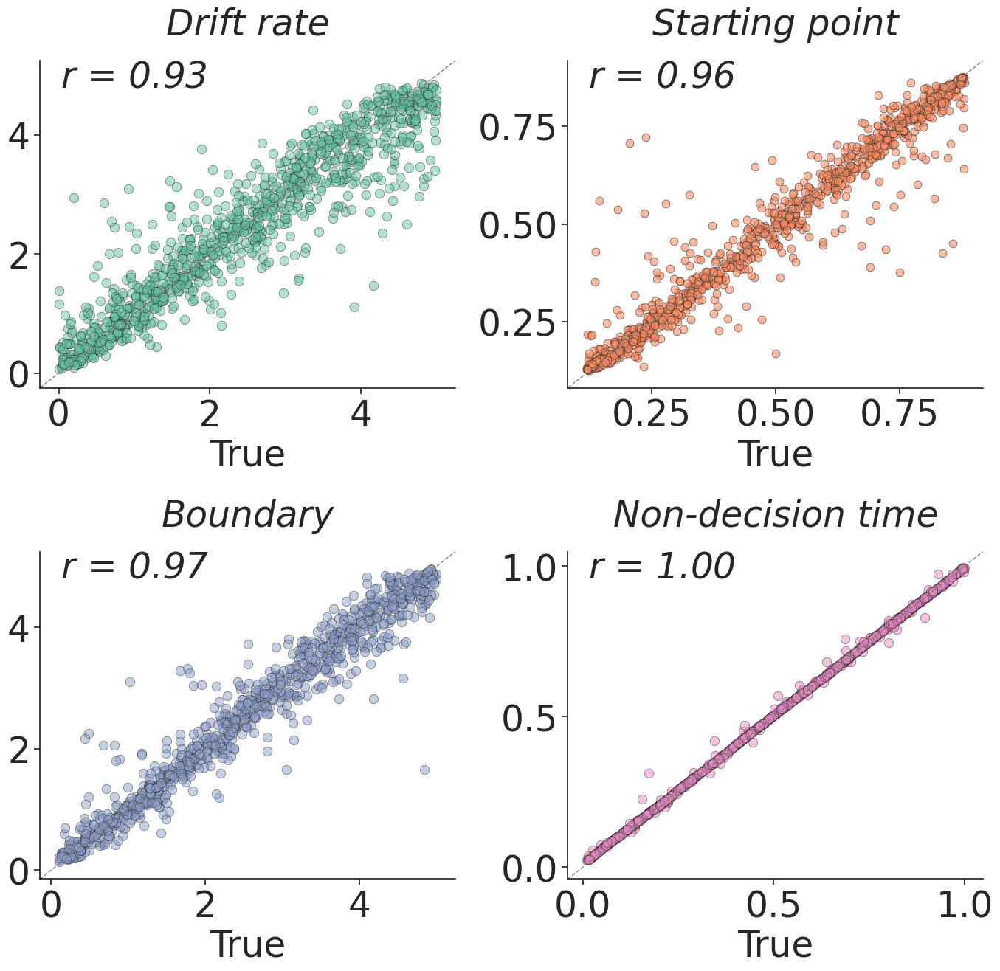

In [22]:

#shared_param_labels = ["Drift rate $v$", "Starting point $z$", "Boundary $a$", "Non-decision time $T_{er}$"]
shared_param_labels = ["Drift rate", "Starting point", "Boundary", "Non-decision time"]

# Set seaborn style
sns.set(style="ticks", font_scale=1.7)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for i, ax in enumerate(axes.flatten()):
    if i < len(shared_param_labels):
        
        if i == 1:
            ax.scatter(1/(1+np.exp(-true_shared[:, i])), 1/(1+np.exp(-estimated_shared_mean[:, i])),
                       alpha=0.6, s=60, edgecolor='k', linewidth=0.6, color=sns.color_palette("Set2")[i])
        
        else:
            ax.scatter(true_shared[:, i], estimated_shared_mean[:, i],
                   alpha=0.5, s=80, edgecolor='k', linewidth=0.6, color=sns.color_palette("Set2")[i])
        # Labels and title
        ax.set_xlabel("True", fontsize=fontsize)
        #ax.set_ylabel("Inferred", fontsize=fontsize)
        ax.set_title(shared_param_labels[i], fontsize=fontsize, style='italic',pad=25)
        
        if i == 1:
            x = 1/(1+np.exp(-true_shared[:, i]))
            y = 1/(1+np.exp(-estimated_shared_mean[:, i]))
        else:
            x = true_shared[:, i]
            y = estimated_shared_mean[:, i]

        # Spearman correlation
        r, _ = pearsonr(true_shared[:, i], estimated_shared_mean[:, i])
        ax.annotate(f'$r$ = {r:.2f}', xy=(0.05, 0.92),
                    xycoords='axes fraction', fontsize=fontsize, style='italic')

        # Identity line
        min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
        max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='gray', linewidth=1)
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.tick_params(labelsize=fontsize)

        # Clean up
        sns.despine(ax=ax)
    else:
        ax.axis('off')

# Title and layout
#fig.suptitle("Shared Parameters Recovery", fontsize=26, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.5)
plt.savefig('Figures/recovery_autocorrelated_ddm_shared_params.png', dpi=300)
plt.show()

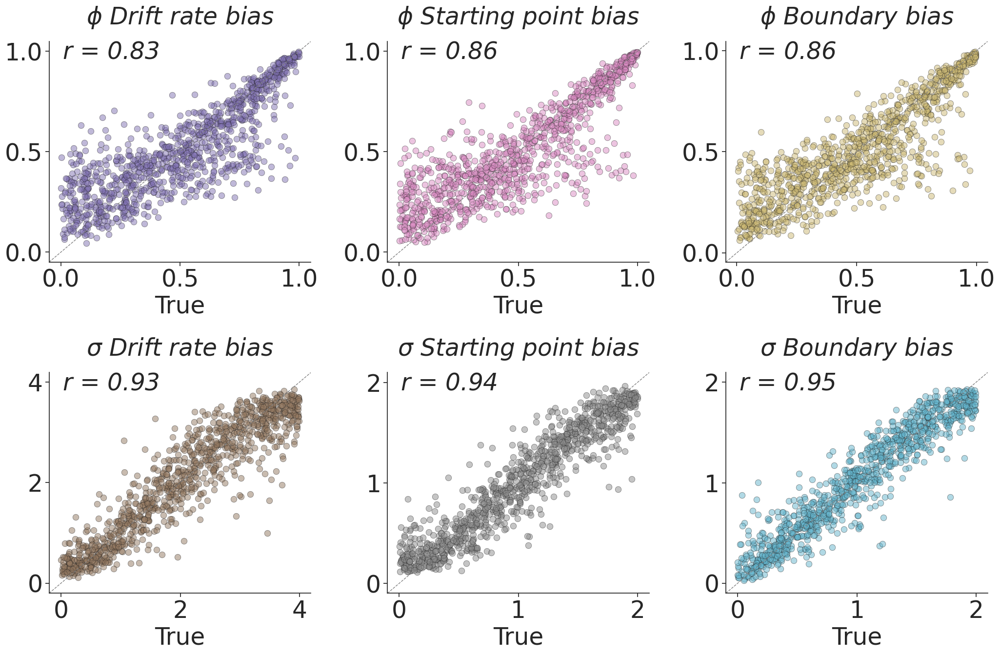

In [23]:
hyper_param_labels = ["$\phi$ Drift rate bias","$\sigma$ Drift rate bias","$\phi$ Starting point bias","$\sigma$ Starting point bias","$\phi$ Boundary bias","$\sigma$ Boundary bias"]

sns.set(style="ticks")

# Use a different color palette to avoid overlap with 'Set2'
colors = sns.color_palette()
colors = colors[4:10]

plot_order = [0, 2, 4, 1, 3, 5] # first all phi, then all sigma

fig, axes = plt.subplots(2, 3, figsize=(21, 14))

for ax, i in zip(axes.flatten(), plot_order):
    # Scatter plot
    ax.scatter(true_hyper[:, i], estimated_hyper_mean[:, i],
               alpha=0.5, s=80, edgecolor='k', linewidth=0.6, color=colors[i])
    
    # Axes labels and title
    ax.set_xlabel("True", fontsize=fontsize)
    #ax.set_ylabel("Inferred", fontsize=fontsize)
    ax.set_title(hyper_param_labels[i], fontsize=fontsize, style='italic', pad=25) #weight='bold'

    # Pearson correlation
    r, _ = pearsonr(true_hyper[:, i], estimated_hyper_mean[:, i])
    ax.annotate(f'$r$ = {r:.2f}', xy=(0.05, 0.92),
                xycoords='axes fraction', fontsize=fontsize, style='italic')

    # Identity line
    min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='gray', linewidth=1)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.tick_params(axis='both', labelsize=fontsize)

    # Despine
    sns.despine(ax=ax)

# Title and layout
#fig.suptitle("Hyperparameters Recovery", fontsize=26, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.subplots_adjust(hspace=0.5)
plt.savefig("Figures/recovery_autocorrelated_ddm_hyper_params.png", dpi=300)
plt.show()

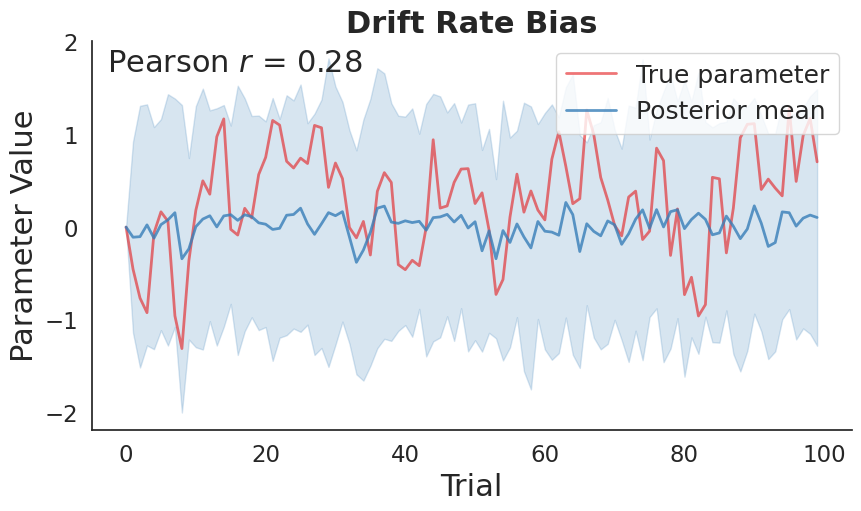

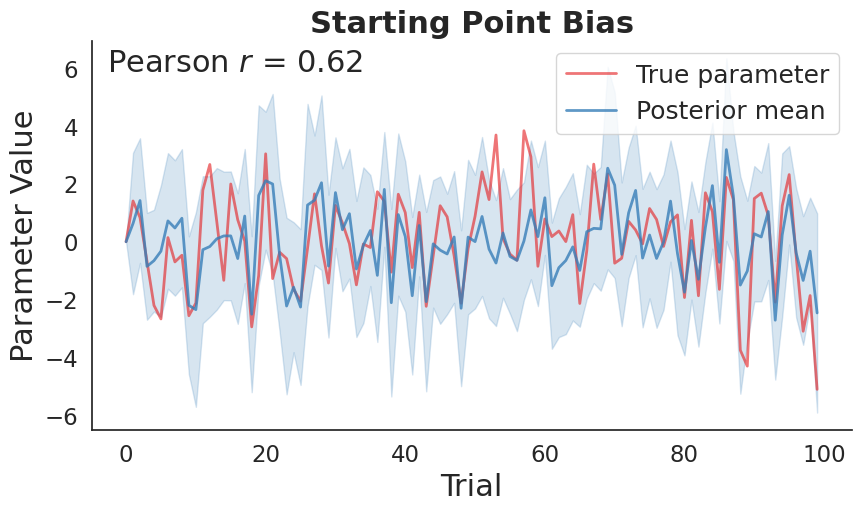

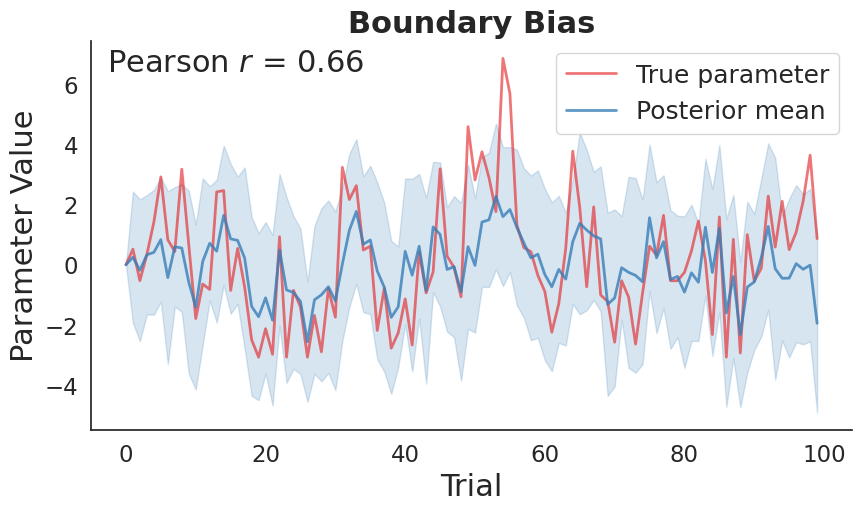

In [24]:
# Styling
sns.set(style="white", font_scale=1.5)
colors = sns.color_palette("Set1", n_colors=2)

param_labels = ["Drift Rate Bias", "Starting Point Bias", "Boundary Bias"]
upper = 100  # or num_trials
example_id = 3

# Plot each parameter separately
for col in range(3):
    fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True)

    # Plot true and estimated parameter time series
    ax.plot(np.arange(upper),
            true_local[example_id, :upper, col],
            color=colors[0], label="True parameter", alpha=0.6, linewidth=2)

    ax.plot(np.arange(upper),
            estimated_local_mean[example_id, :upper, col],
            color=colors[1], label="Posterior mean", alpha=0.8, linewidth=2)
    
    # Optional: Add posterior std band (comment to toggle)
    ax.fill_between(np.arange(upper),
                    estimated_local_mean[example_id, :upper, col] - 1.96 * estimated_local_std[example_id, :upper, col],
                    estimated_local_mean[example_id, :upper, col] + 1.96 * estimated_local_std[example_id, :upper, col],
                    alpha=0.2, color=colors[1])

    # Metrics
    r, _ = pearsonr(estimated_local_mean[example_id, :, col], true_local[example_id, :, col])
    #mse = np.mean((estimated_local_mean[example_id, :, col] - true_local[example_id, :, col]) ** 2)
    #r2 = r2_score(true_local[example_id, :, col], estimated_local_mean[example_id, :, col])

    ax.annotate(f"Pearson $r$ = {r:.2f}", xy=(0.02, 0.92), xycoords='axes fraction', fontsize=22)
    #ax.annotate(f"MSE = {mse:.2f}", xy=(0.02, 0.90), xycoords='axes fraction', fontsize=13)
    #ax.annotate(f"$R^2$ = {r2:.2f}", xy=(0.02, 0.85), xycoords='axes fraction', fontsize=13)

    # Labels
    ax.set_xlabel("Trial", fontsize=22)
    ax.set_ylabel("Parameter Value", fontsize=22)
    ax.set_title(param_labels[col], fontsize=22, weight="bold")

    # Legend and cleanup
    ax.legend(loc="upper right", fontsize=18)
    sns.despine()
    plt.show()

## Recoverability trajectories in function of generative parameters

In [25]:
correlation_v_bias = []
correlation_z_bias = []
correlation_a_bias = []

rmse_v_bias = []
rmse_z_bias = []
rmse_a_bias = []

r2_v_bias = []
r2_z_bias = []
r2_a_bias = []

for sim in range(num_simulations):
    r_v_bias, _= spearmanr(estimated_local_mean[sim,:,0], true_local[sim,:,0])
    r_z_bias, _= spearmanr(estimated_local_mean[sim,:,1], true_local[sim,:,1])
    r_a_bias, _= spearmanr(estimated_local_mean[sim,:,2], true_local[sim,:,2])
    rmse_v = np.sqrt(sum((estimated_local_mean[sim,:,0] - true_local[sim,:,0])**2)/len(true_local[sim,:,0]))
    rmse_z = np.sqrt(sum((estimated_local_mean[sim,:,1] - true_local[sim,:,1])**2)/len(true_local[sim,:,1]))
    rmse_a = np.sqrt(sum((estimated_local_mean[sim,:,2] - true_local[sim,:,2])**2)/len(true_local[sim,:,2]))
    
    correlation_v_bias.append(r_v_bias)
    correlation_z_bias.append(r_z_bias)
    correlation_a_bias.append(r_a_bias)
    
    rmse_v_bias.append(rmse_v)
    rmse_z_bias.append(rmse_z)
    rmse_a_bias.append(rmse_a)

### Drift rate bias

In [26]:
fontsize_heatmap = 44

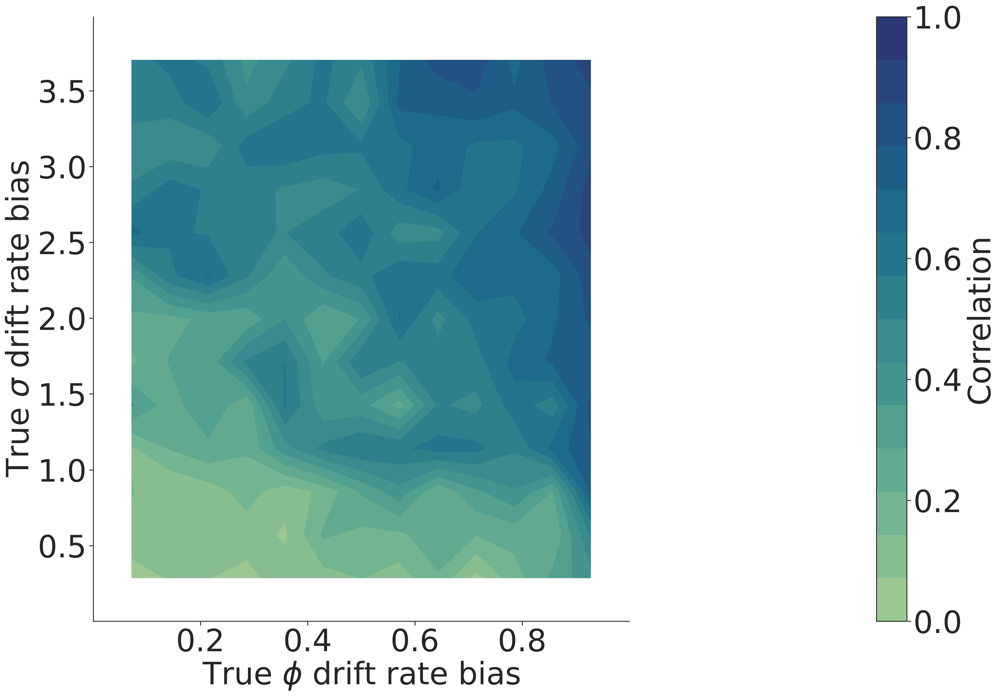

In [27]:
num_levels = 15 #25

sns.set(style="ticks")

# Set up grid for interpolation
x = true_hyper[:, 0]
y = true_hyper[:, 1]
z = correlation_v_bias

# Create a grid to interpolate onto
xi = np.linspace(x.min(), x.max(), num_levels)
yi = np.linspace(y.min(), y.max(), num_levels)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the z-values onto the grid
zi = griddata((x, y), z, (xi, yi), method='linear')
zi = np.clip(zi, 0, 1)

fig, ax = plt.subplots(figsize=(20, 14), dpi=300)
levels = np.linspace(0, 1, num_levels)

contour = ax.contourf(
    xi, yi, zi,
    levels=levels,
    cmap="crest",
    vmin=0,
    vmax=1
)

ax.set_xlabel(r"True $\phi$ drift rate bias", fontsize=fontsize_heatmap)
ax.set_ylabel(r"True $\sigma$ drift rate bias", fontsize=fontsize_heatmap)
ax.tick_params(axis="both", labelsize=fontsize_heatmap)


# Colorbar
cbar = fig.colorbar(
    contour,
    ax=ax,
    #orientation="horizontal",
    pad=.3,   # space between plot and colorbar
    fraction=0.05  # thickness of the colorbar
)
cbar.set_label("Correlation", fontsize=fontsize_heatmap)
cbar.set_ticks(np.linspace(0, 1, 6))

cbar.ax.tick_params(labelsize=fontsize_heatmap)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("Figures/heatmap_driftratebias_legend.png")
plt.show()

### Drift rate bias (without legend)

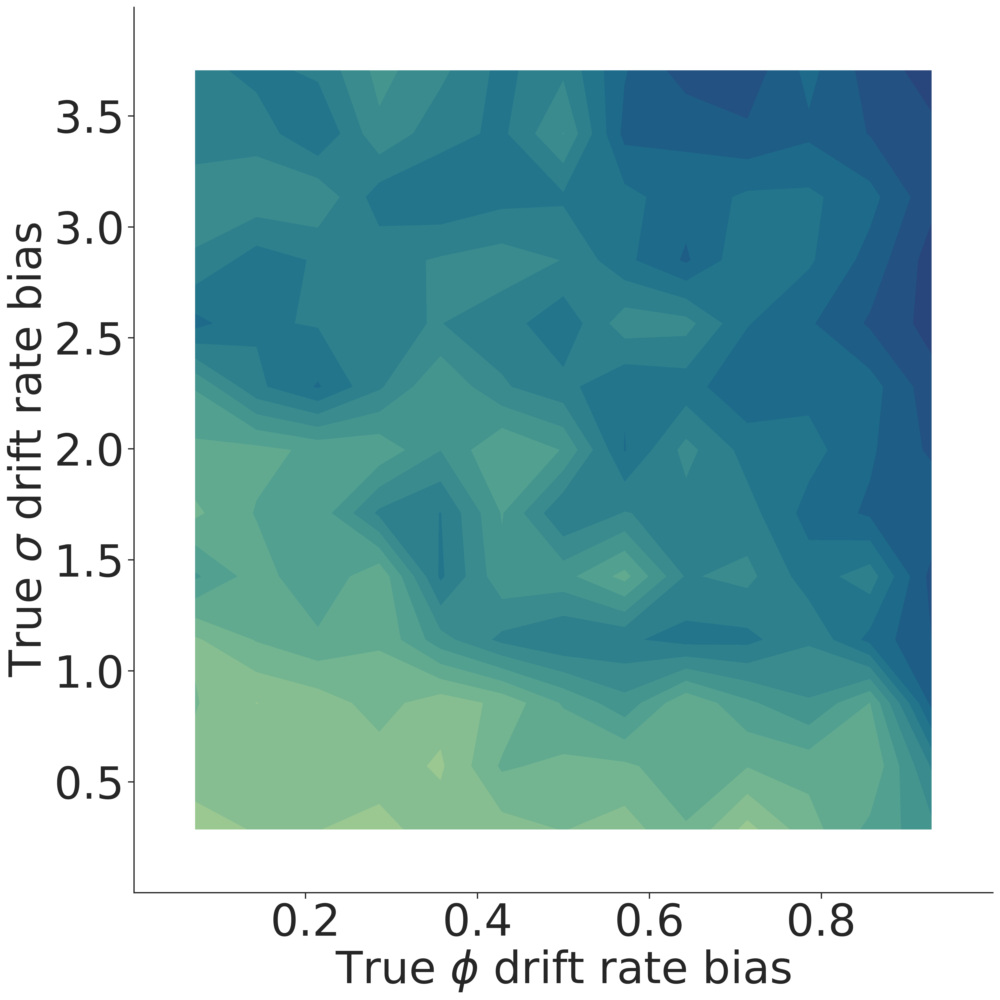

In [28]:
sns.set(style="ticks")

# Set up grid for interpolation
x = true_hyper[:, 0]
y = true_hyper[:, 1]
z = correlation_v_bias

# Create a grid to interpolate onto
xi = np.linspace(x.min(), x.max(), num_levels)
yi = np.linspace(y.min(), y.max(), num_levels)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the z-values onto the grid
zi = griddata((x, y), z, (xi, yi), method='linear')
zi = np.clip(zi, 0, 1)

fig, ax = plt.subplots(figsize=(14, 14), dpi=300)
levels = np.linspace(0, 1, num_levels)

contour = ax.contourf(
    xi, yi, zi,
    levels=levels,
    cmap="crest",
    vmin=0,
    vmax=1
)

ax.set_xlabel(r"True $\phi$ drift rate bias", fontsize=fontsize_heatmap)
ax.set_ylabel(r"True $\sigma$ drift rate bias", fontsize=fontsize_heatmap)
ax.tick_params(axis="both", labelsize=fontsize_heatmap)


# Colorbar
# cbar = fig.colorbar(contour, ax=ax)
# cbar.set_label("Correlation", fontsize=fontsize)
# cbar.set_ticks(np.linspace(0, 1, 6))

# cbar.ax.tick_params(labelsize=fontsize)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("Figures/heatmap_driftratebias.png")
plt.show()

### Starting point bias (without legend)

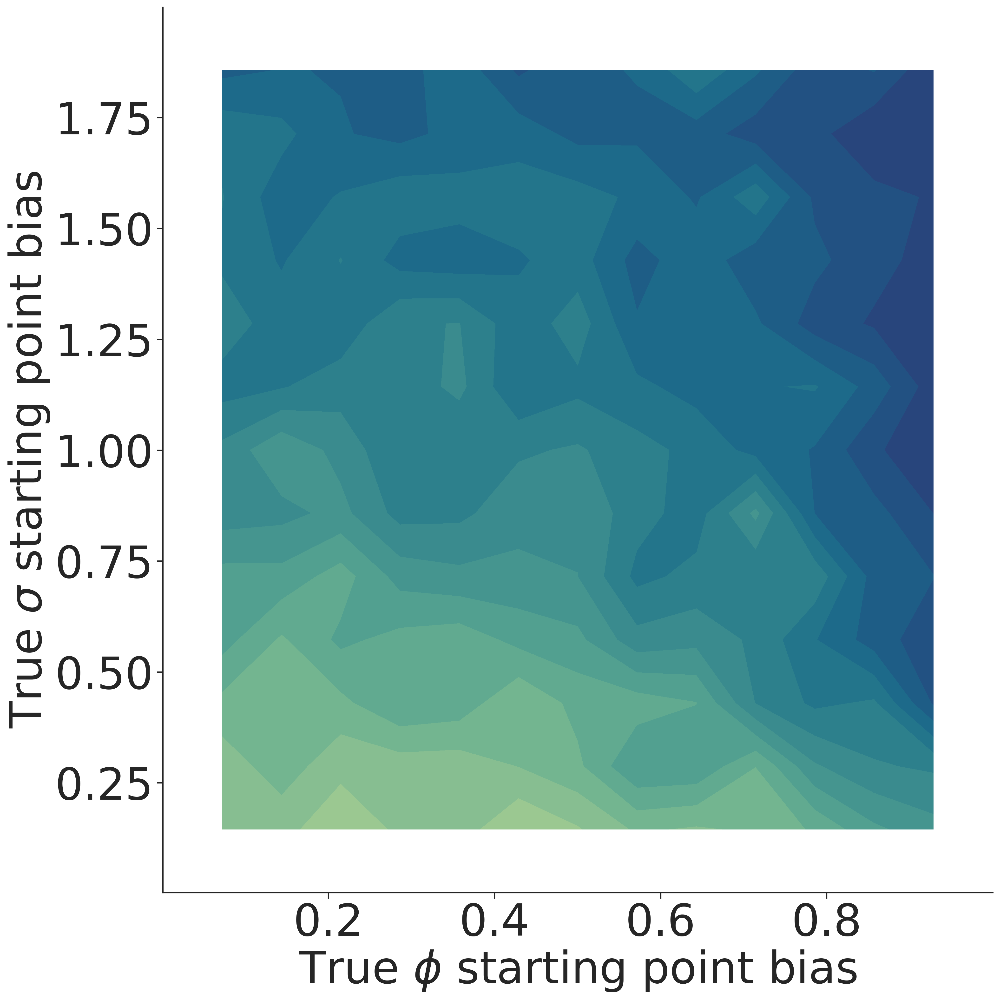

In [29]:
sns.set(style="ticks")

# Set up grid for interpolation
x = true_hyper[:, 2]
y = true_hyper[:, 3]
z = correlation_z_bias

# Create a grid to interpolate onto
xi = np.linspace(x.min(), x.max(), num_levels)
yi = np.linspace(y.min(), y.max(), num_levels)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the z-values onto the grid
zi = griddata((x, y), z, (xi, yi), method='linear')
zi = np.clip(zi, 0, 1)

fig, ax = plt.subplots(figsize=(14, 14), dpi=300)
levels = np.linspace(0, 1, num_levels)

contour = ax.contourf(
    xi, yi, zi,
    levels=levels,
    cmap="crest",
    vmin=0,
    vmax=1
)

ax.set_xlabel(r"True $\phi$ starting point bias", fontsize=fontsize_heatmap)
ax.set_ylabel(r"True $\sigma$ starting point bias", fontsize=fontsize_heatmap)
ax.tick_params(axis="both", labelsize=fontsize_heatmap)

# Colorbar
# cbar = fig.colorbar(contour, ax=ax)
# cbar.set_label("Correlation", fontsize=fontsize)
# cbar.set_ticks(np.linspace(0, 1, 6))

# cbar.ax.tick_params(labelsize=fontsize)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("Figures/heatmap_startingpointbias.png")
plt.show()

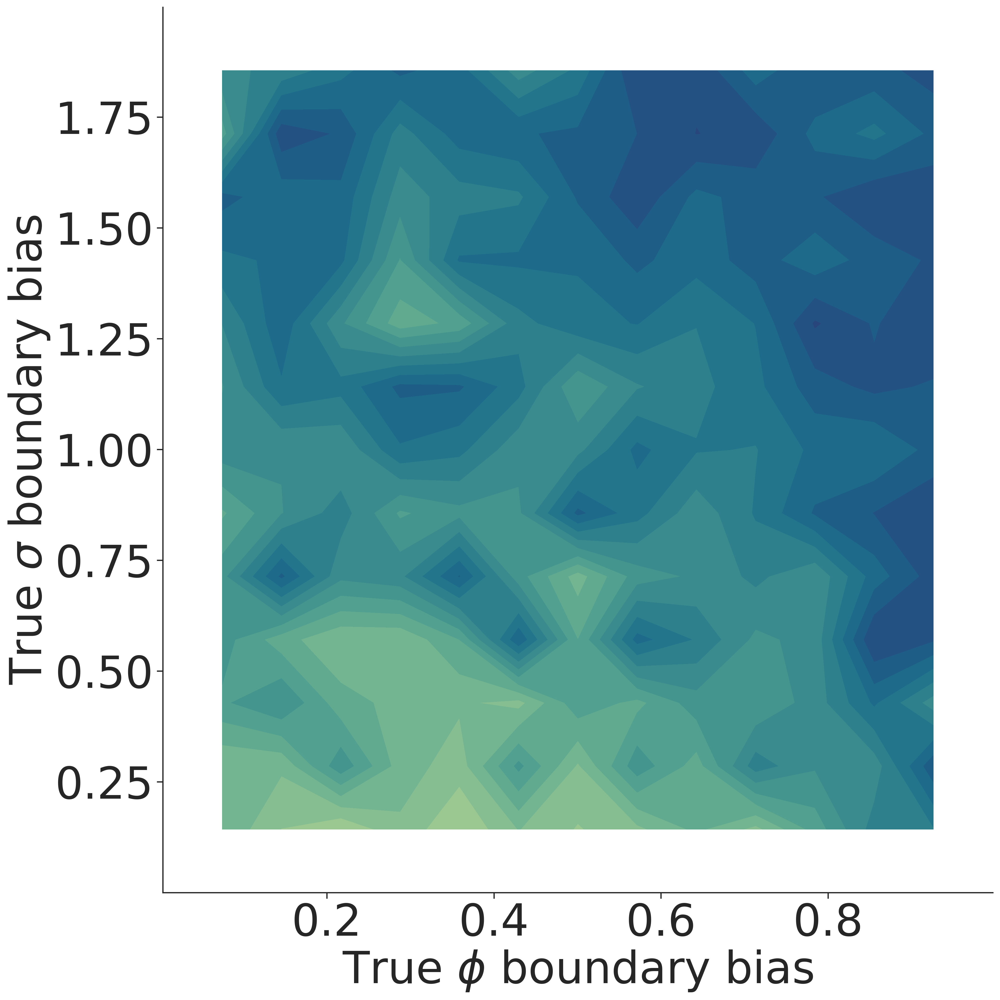

In [30]:
sns.set(style="ticks")

# Set up grid for interpolation
x = true_hyper[:, 4]
y = true_hyper[:, 5]
z = correlation_a_bias

# Create a grid to interpolate onto
xi = np.linspace(x.min(), x.max(), num_levels)
yi = np.linspace(y.min(), y.max(), num_levels)
xi, yi = np.meshgrid(xi, yi)

# Interpolate the z-values onto the grid
zi = griddata((x, y), z, (xi, yi), method='linear')
zi = np.clip(zi, 0, 1)

fig, ax = plt.subplots(figsize=(14, 14), dpi=300)
levels = np.linspace(0, 1, num_levels)

contour = ax.contourf(
    xi, yi, zi,
    levels=levels,
    cmap="crest",
    vmin=0,
    vmax=1,
    antialiased=False
)
    
ax.set_xlabel(r"True $\phi$ boundary bias", fontsize=fontsize_heatmap)
ax.set_ylabel(r"True $\sigma$ boundary bias", fontsize=fontsize_heatmap)
ax.tick_params(axis="both", labelsize=fontsize_heatmap)

# Colorbar
# cbar = fig.colorbar(contour, ax=ax)
# cbar.set_label("Correlation", fontsize=fontsize)
# cbar.set_ticks(np.linspace(0, 1, 6))

# cbar.ax.tick_params(labelsize=fontsize)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("Figures/heatmap_boundarybias.png")
plt.show()

## 2. Simulation-based calibration (SBC)

Generate data with true posterior mean, then fit data, and calculate the rank statistic of that true posterior mean in the estimated posterior. 

If unbiased then there should be a uniform distribution.

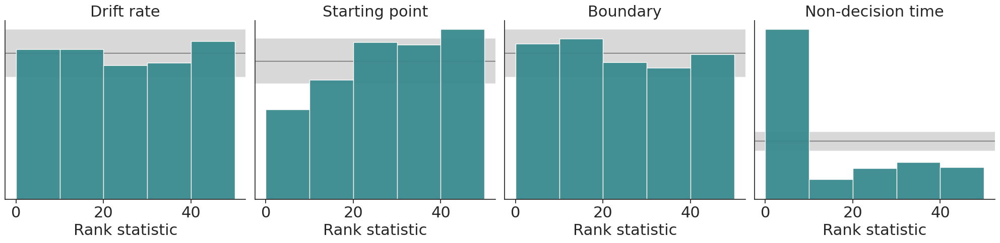

In [31]:
f = bf.diagnostics.plot_sbc_histograms(estimated_shared, true_shared, num_bins=5, param_names=shared_param_labels, 
                                       hist_color="#38898E", label_fontsize=22, title_fontsize=22, tick_fontsize=22)
f.savefig("Figures/sbc_shared.png", dpi=300)

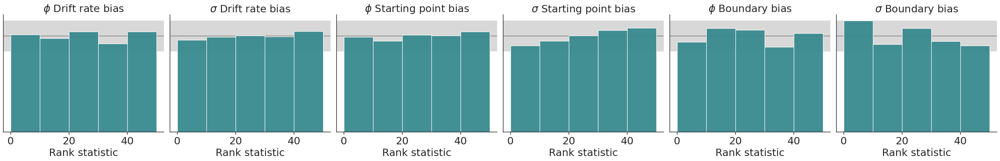

In [32]:
f = bf.diagnostics.plot_sbc_histograms(estimated_hyper, true_hyper, num_bins=5, param_names=hyper_param_labels,
                                       hist_color="#38898E", label_fontsize=22, title_fontsize=22, tick_fontsize=22)
f.savefig("Figures/sbc_hyper.png", dpi=300)

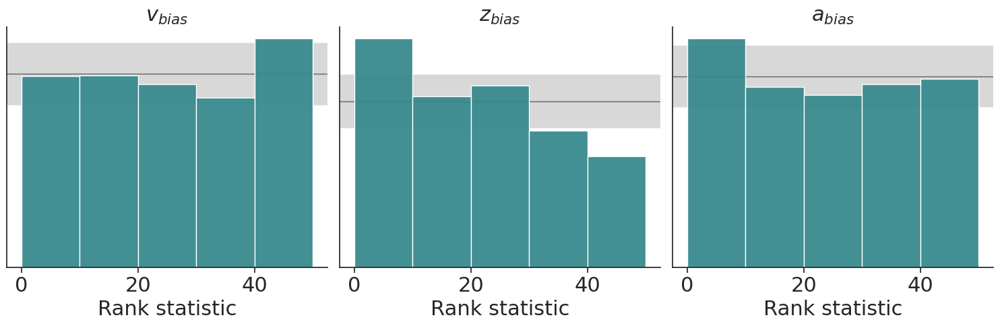

In [33]:
# vbias and zbias at a random trial
PARAM_NAMES=[r"$v_{bias}$",r"$z_{bias}$",r"$a_{bias}$"]
trial_id = 5
f = bf.diagnostics.plot_sbc_histograms(estimated_local[:,trial_id,:,:], true_local[:,trial_id,:], num_bins=5, param_names=PARAM_NAMES,
                                      hist_color="#38898E", label_fontsize=22, title_fontsize=22, tick_fontsize=22)
f.savefig("Figures/sbc_local.png", dpi=300)

## 3. Posterior z-score vs posterior contraction

Posterior z-score: if your posterior is well-calibrated and centered, the values should be distributed like a standard normal (unbiased when mean = 0, correct uncertainty calibration when variance = 1)

Posterior contraction: 
measures how much the posterior shrinks relative to the prior — i.e., how informative the data are for that parameter. If 0 then posterior variance = prior variance so data were not informative. If close to 1 then good learning

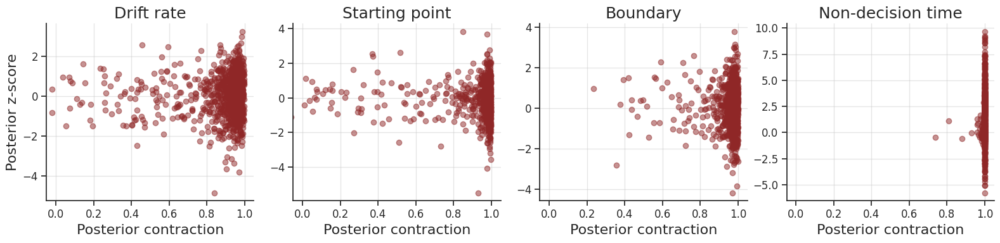

In [34]:
f = bf.diagnostics.plot_z_score_contraction(
    estimated_shared, 
    true_shared,
    param_names=shared_param_labels
)

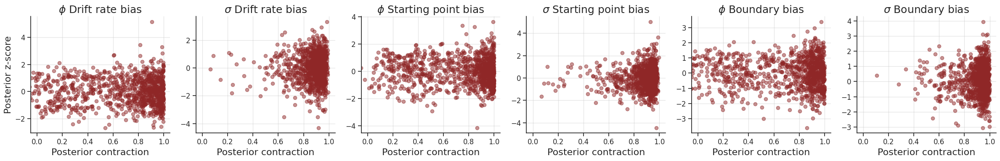

In [35]:
f = bf.diagnostics.plot_z_score_contraction(
    estimated_hyper, 
    true_hyper,
    param_names=hyper_param_labels
)

## 4. RT distributions

1) Simulate data with our generative model.
2) Fit the model to these data.
3) Resimulate new data with samples from the obtained posterior.
4) Compare (summary of) the simulated data and the resimulated data (model prediction).

In [36]:
# Define re-simulation settings
num_simulated_datasets = 8
num_posterior_samples = 100
num_resimulated_datasets = 8

mean_shared, std_shared = return_mean_std_shared_parameters()
mean_hyper, std_hyper = return_mean_std_hyper_parameters()

In [37]:
all_simulated_data = np.zeros((num_simulated_datasets, num_trials, 3))
all_predicted_data = np.zeros((num_simulated_datasets, num_trials, 3))

for dataset in range(num_simulated_datasets):

    # Step 1
    simulated = generator(batch_size=1)
    configurated_data = trainer.configurator(simulated)

    # Step 2
    posterior_samples = amortizer.sample(
        configurated_data,
        n_samples=num_posterior_samples,
    )

    # Unstandardize posterior draws
    estimated_shared = (
        posterior_samples["global_samples"][:, 6:11] * std_shared + mean_shared
    )
    estimated_local = posterior_samples["local_samples"] * 5

    # Posterior means
    estimated_shared = estimated_shared[None, ...]
    estimated_local = estimated_local[None, ...]

    estimated_posterior_means_shared = estimated_shared.mean(axis=1)
    estimated_posterior_means_local = estimated_local.mean(axis=2)

    # Step 3
    num_obs = simulated["sim_data"].shape[1]

    parameters = (
        estimated_posterior_means_local.reshape(1, num_obs, 3),
        estimated_posterior_means_shared,
    )

    context = simulated["sim_batchable_context"]

    predicted = sample_multiple_diffusion_trials(parameters, context)

    # Extract the (num_trials, 2) arrays
    sim_data = simulated["sim_data"][0]
    pred_data = predicted[0]

    # Flatten context for batch dimension
    context = np.squeeze(context)

    # Accuracy
    accuracy_simulated = (
        ((np.sign(context) == 1) & (sim_data[:, 1] == 1))
        | ((np.sign(context) == -1) & (sim_data[:, 1] == 0))
    ).astype(int)

    accuracy_predicted = (
        ((np.sign(context) == 1) & (pred_data[:, 1] == 1))
        | ((np.sign(context) == -1) & (pred_data[:, 1] == 0))
    ).astype(int)

    # Add accuracy as third column
    sim_data = np.column_stack((sim_data, accuracy_simulated))
    pred_data = np.column_stack((pred_data, accuracy_predicted))

    # Save
    all_simulated_data[dataset] = sim_data
    all_predicted_data[dataset] = pred_data

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


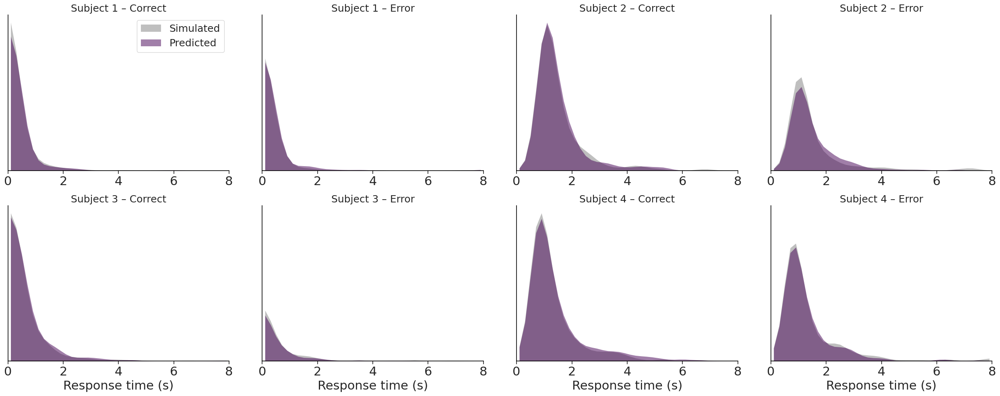

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d

# ==================================================
# Colors
# ==================================================

sim_color = "gray"
pred_color = "#440154"

sim_alpha = 0.5
pred_alpha = 0.5

# ==================================================
# Figure
# ==================================================

f, axarr = plt.subplots(
    2, 4,
    figsize=(25, 10)
)

# ==================================================
# Histogram settings
# ==================================================

# Same bins for every subject and condition
bins = np.linspace(0, 8, 41)

# Bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2

# Gaussian smoothing
sigma = 1.5

# ==================================================
# Loop over subjects
# ==================================================

for subject in range(4):

    # --------------------------------------------------
    # Determine subplot positions
    # --------------------------------------------------

    row = subject // 2
    col = (subject % 2) * 2

    ax_correct = axarr[row, col]
    ax_error = axarr[row, col + 1]

    # ==================================================
    # Masks
    # ==================================================

    sim_correct = all_simulated_data[subject, :, 2] == 1
    sim_error = all_simulated_data[subject, :, 2] == 0

    pred_correct = all_predicted_data[subject, :, 2] == 1
    pred_error = all_predicted_data[subject, :, 2] == 0

    # ==================================================
    # Extract response times
    # ==================================================

    sim_correct_rt = all_simulated_data[
        subject, sim_correct, 0
    ]

    sim_error_rt = all_simulated_data[
        subject, sim_error, 0
    ]

    pred_correct_rt = all_predicted_data[
        subject, pred_correct, 0
    ]

    pred_error_rt = all_predicted_data[
        subject, pred_error, 0
    ]

    # ==================================================
    # Histograms
    # ==================================================

    sim_correct_counts, _ = np.histogram(
        sim_correct_rt,
        bins=bins
    )

    sim_error_counts, _ = np.histogram(
        sim_error_rt,
        bins=bins
    )

    pred_correct_counts, _ = np.histogram(
        pred_correct_rt,
        bins=bins
    )

    pred_error_counts, _ = np.histogram(
        pred_error_rt,
        bins=bins
    )

    # ==================================================
    # Smooth histograms
    # ==================================================

    sim_correct_smooth = gaussian_filter1d(
        sim_correct_counts.astype(float),
        sigma=sigma
    )

    sim_error_smooth = gaussian_filter1d(
        sim_error_counts.astype(float),
        sigma=sigma
    )

    pred_correct_smooth = gaussian_filter1d(
        pred_correct_counts.astype(float),
        sigma=sigma
    )

    pred_error_smooth = gaussian_filter1d(
        pred_error_counts.astype(float),
        sigma=sigma
    )

    # ==================================================
    # Shared y-axis within subject
    # ==================================================

    ymax = max(
        np.max(sim_correct_smooth),
        np.max(pred_correct_smooth),
        np.max(sim_error_smooth),
        np.max(pred_error_smooth)
    )

    # ==================================================
    # Subject - Correct
    # ==================================================

    ax_correct.fill_between(
        bin_centers,
        0,
        sim_correct_smooth,
        color=sim_color,
        alpha=sim_alpha,
        linewidth=0
    )

    ax_correct.fill_between(
        bin_centers,
        0,
        pred_correct_smooth,
        color=pred_color,
        alpha=pred_alpha,
        linewidth=0
    )

    ax_correct.set_title(
        f"Subject {subject + 1} – Correct",
        fontsize=18
    )

    # ==================================================
    # Subject - Error
    # ==================================================

    ax_error.fill_between(
        bin_centers,
        0,
        sim_error_smooth,
        color=sim_color,
        alpha=sim_alpha,
        linewidth=0
    )

    ax_error.fill_between(
        bin_centers,
        0,
        pred_error_smooth,
        color=pred_color,
        alpha=pred_alpha,
        linewidth=0
    )

    ax_error.set_title(
        f"Subject {subject + 1} – Error",
        fontsize=18
    )

    # ==================================================
    # Same y-axis for Correct and Error
    # ==================================================

    ax_correct.set_ylim(0, ymax * 1.05)
    ax_error.set_ylim(0, ymax * 1.05)

    # ==================================================
    # Formatting
    # ==================================================

    for ax in (ax_correct, ax_error):

        ax.set_xlim(0, 8)

        # No y-axis labels or ticks
        ax.set_ylabel("")
        ax.set_yticks([])

        # X-axis
        ax.tick_params(
            axis="x",
            labelsize=22
        )

        # --------------------------------------------------
        # Spines
        # --------------------------------------------------

        # Hide top and right
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # KEEP BLACK Y-AXIS
        ax.spines["left"].set_visible(True)
        ax.spines["left"].set_color("black")
        ax.spines["left"].set_linewidth(1.2)

        # Keep bottom axis black as well
        ax.spines["bottom"].set_visible(True)
        ax.spines["bottom"].set_color("black")
        ax.spines["bottom"].set_linewidth(1.2)

    # ==================================================
    # Legend
    # ==================================================

    if subject == 0:

        legend_handles = [
            Patch(
                facecolor=sim_color,
                edgecolor="none",
                alpha=sim_alpha,
                label="Simulated"
            ),
            Patch(
                facecolor=pred_color,
                edgecolor="none",
                alpha=pred_alpha,
                label="Predicted"
            )
        ]

        ax_correct.legend(
            handles=legend_handles,
            fontsize=18,
            frameon=True
        )

# ==================================================
# X-axis labels
# ==================================================

for ax in axarr[1]:
    ax.set_xlabel(
        "Response time (s)",
        fontsize=22
    )

# ==================================================
# Layout
# ==================================================

f.tight_layout()

f.subplots_adjust(
    wspace=0.15
)

# ==================================================
# Save
# ==================================================

plt.savefig(
    "Figures/predicted_rt_dist_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

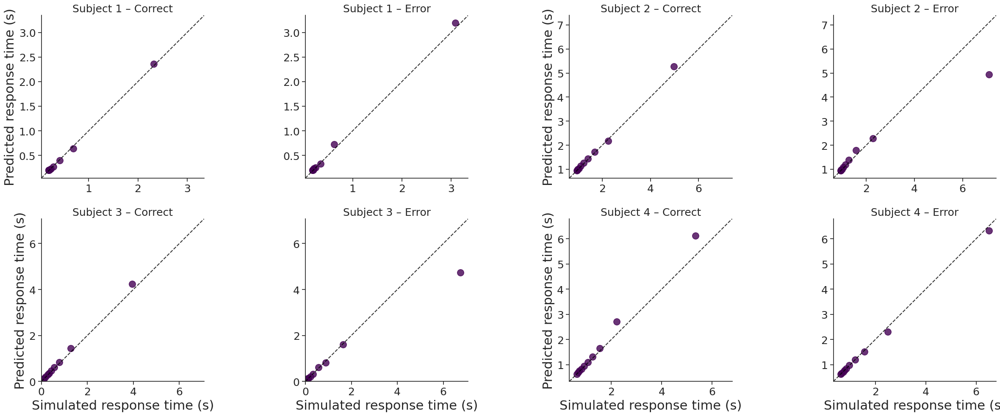

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================================
# Figure
# ==========================================================

f, axarr = plt.subplots(
    2,
    4,
    figsize=(25, 10)
)


# ==========================================================
# Quantiles to compare
# ==========================================================

quantiles = np.linspace(
    0.01,
    0.99,
    10
)


# ==========================================================
# Loop over subjects
# ==========================================================

for subject in range(4):

    # ------------------------------------------------------
    # Determine subplot positions
    # ------------------------------------------------------

    row = subject // 2
    col = (subject % 2) * 2

    ax_correct = axarr[row, col]
    ax_error = axarr[row, col + 1]


    # ======================================================
    # Masks
    # ======================================================

    sim_correct = (
        all_simulated_data[subject, :, 2] == 1
    )

    sim_error = (
        all_simulated_data[subject, :, 2] == 0
    )

    pred_correct = (
        all_predicted_data[subject, :, 2] == 1
    )

    pred_error = (
        all_predicted_data[subject, :, 2] == 0
    )


    # ======================================================
    # Correct trials
    # ======================================================

    sim_correct_rt = all_simulated_data[
        subject,
        sim_correct,
        0
    ]

    pred_correct_rt = all_predicted_data[
        subject,
        pred_correct,
        0
    ]

    # Calculate corresponding quantiles
    sim_q_correct = np.quantile(
        sim_correct_rt,
        quantiles
    )

    pred_q_correct = np.quantile(
        pred_correct_rt,
        quantiles
    )


    # ======================================================
    # Error trials
    # ======================================================

    sim_error_rt = all_simulated_data[
        subject,
        sim_error,
        0
    ]

    pred_error_rt = all_predicted_data[
        subject,
        pred_error,
        0
    ]

    # Calculate corresponding quantiles
    sim_q_error = np.quantile(
        sim_error_rt,
        quantiles
    )

    pred_q_error = np.quantile(
        pred_error_rt,
        quantiles
    )


    # ======================================================
    # Determine bounds for this subject
    # ======================================================
    #
    # Use ALL quantiles from:
    #
    #   - simulated correct
    #   - predicted correct
    #   - simulated error
    #   - predicted error
    #
    # This guarantees that both panels for a subject use
    # exactly the same x/y range.
    #

    all_quantiles = np.concatenate([
        sim_q_correct,
        pred_q_correct,
        sim_q_error,
        pred_q_error
    ])

    lower = np.min(all_quantiles)
    upper = np.max(all_quantiles)

    # Add 5% margin around the data
    margin = 0.05 * (upper - lower)

    lower = lower - margin
    upper = upper + margin

    # RTs cannot be negative
    lower = max(0, lower)


    # ======================================================
    # Correct QQ plot
    # ======================================================

    ax_correct.scatter(
        sim_q_correct,
        pred_q_correct,
        s=125,
        alpha=0.8,
        color="#440154"
    )

    # Perfect agreement line
    ax_correct.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        color="black",
        linewidth=1.5,
        alpha=0.8
    )

    ax_correct.set_title(
        f"Subject {subject + 1} – Correct",
        fontsize=18
    )


    # ======================================================
    # Error QQ plot
    # ======================================================

    ax_error.scatter(
        sim_q_error,
        pred_q_error,
        s=125,
        alpha=0.8,
        color="#440154"
    )

    # Perfect agreement line
    ax_error.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        color="black",
        linewidth=1.5,
        alpha=0.8
    )

    ax_error.set_title(
        f"Subject {subject + 1} – Error",
        fontsize=18
    )


    # ======================================================
    # Formatting
    # ======================================================

    for ax in (ax_correct, ax_error):

        # Same limits for x and y
        ax.set_xlim(
            lower,
            upper
        )

        ax.set_ylim(
            lower,
            upper
        )

        # Equal aspect ratio
        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        # Axis labels
        ax.set_xlabel(
            "Simulated response time (s)",
            fontsize=22
        )

        ax.set_ylabel(
            "Predicted response time (s)",
            fontsize=22
        )

        # Tick size
        ax.tick_params(
            axis="both",
            labelsize=18
        )

        # Remove top/right spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)


# ==========================================================
# Only show x labels on bottom row
# ==========================================================

for ax in axarr[0]:
    ax.set_xlabel("")


# ==========================================================
# Keep y labels only on left-most panels
# ==========================================================

for ax in [
    axarr[0, 1],
    axarr[0, 3],
    axarr[1, 1],
    axarr[1, 3]
]:
    ax.set_ylabel("")


# ==========================================================
# Layout
# ==========================================================

f.tight_layout()

f.subplots_adjust(
    wspace=0.15,
    hspace=0.25
)


# ==========================================================
# Save
# ==========================================================

plt.savefig(
    "Figures/predicted_rt_qq_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()